In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
stunting_data = {
    'Provinsi': ['ACEH', 'SUMATERA UTARA', 'SUMATERA BARAT', 'RIAU', 'JAMBI', 'SUMATERA SELATAN',
                 'BENGKULU', 'LAMPUNG', 'KEP. BANGKA BELITUNG', 'KEP. RIAU', 'DKI JAKARTA',
                 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR', 'BANTEN', 'BALI',
                 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR', 'KALIMANTAN BARAT', 'KALIMANTAN TENGAH',
                 'KALIMANTAN SELATAN', 'KALIMANTAN TIMUR', 'KALIMANTAN UTARA', 'SULAWESI UTARA',
                 'SULAWESI TENGAH', 'SULAWESI SELATAN', 'SULAWESI TENGGARA', 'GORONTALO',
                 'SULAWESI BARAT', 'MALUKU', 'MALUKU UTARA', 'PAPUA BARAT', 'PAPUA BARAT DAYA',
                 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN'],
    'Stunting': [28.6, 17.6, 24.9, 20.1, 13.8, 15.9, 14.9, 14.8, 16.3, 13.7, 14.8, 11.7, 15.0, 15.3,
                 14.4, 17.3, 6.4, 28.7, 34.4, 23.8, 19.1, 22.3, 18.2, 14.7, 15.1, 24.2, 19.6, 23.3,
                 23.6, 35.4, 27.9, 23.2, 24.6, 28.8, 19.1, 20.5, 32.5, 40.0]
}
df_s = pd.DataFrame(stunting_data)

In [ ]:
df_air = pd.read_csv('/content/Persentase Rumah Tangga yang Memiliki Akses terhadap Sumber Air Minum Layak Menurut Provinsi dan Klasifikasi Desa, 2025.csv', skiprows=3, header=None)
df_sanitasi = pd.read_csv('/content/6.2.1_ Persentase rumah tangga yang memiliki akses terhadap sanitasi aman menurut provinsi, 2025.csv', skiprows=2, header=None)
df_miskin = pd.read_csv('/content/Indeks Keparahan Kemiskinan (P2) Menurut Provinsi dan Daerah, 2025.csv', skiprows=3, header=None)

In [ ]:
df_air = df_air.dropna(subset=[0]).copy()
df_air['Provinsi'] = df_air[0].str.strip().str.upper()
df_air['Air_Layak'] = pd.to_numeric(df_air[3], errors='coerce')

In [ ]:
df_sanitasi = df_sanitasi.dropna(subset=[0]).copy()
df_sanitasi['Provinsi'] = df_sanitasi[0].str.strip().str.upper()
df_sanitasi['Sanitasi_Aman'] = pd.to_numeric(df_sanitasi[1], errors='coerce')

In [ ]:
df_miskin = df_miskin.dropna(subset=[0]).copy()
df_miskin['Provinsi'] = df_miskin[0].str.strip().str.upper()
df_miskin['P2_Miskin'] = pd.to_numeric(df_miskin[7], errors='coerce')

In [ ]:
df = df_s.merge(df_air[['Provinsi', 'Air_Layak']], on='Provinsi', how='left')
df = df.merge(df_sanitasi[['Provinsi', 'Sanitasi_Aman']], on='Provinsi', how='left')
df = df.merge(df_miskin[['Provinsi', 'P2_Miskin']], on='Provinsi', how='left')

In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
features = ['Stunting', 'Air_Layak', 'Sanitasi_Aman', 'P2_Miskin']
X = df[features]
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print(df.groupby('Cluster')[features].mean().round(2))

         Stunting  Air_Layak  Sanitasi_Aman  P2_Miskin
Cluster                                               
0           28.21      91.48           3.28       0.56
1           17.26      90.00           9.82       0.25
2           27.58      73.11           4.17       1.42


In [ ]:
cluster_means = df.groupby('Cluster')['Stunting'].mean().sort_values()
cluster_map = {cluster_means.index[0]: 'Klaster C (Terkendali)',
               cluster_means.index[1]: 'Klaster B (Darurat Sanitasi)',
               cluster_means.index[2]: 'Klaster A (Darurat Multisektor)'}
df['Kategori'] = df['Cluster'].map(cluster_map)

In [ ]:
warna_klaster = {
    'Klaster C (Terkendali)': '#2ecc71',         # Hijau
    'Klaster B (Darurat Sanitasi)': '#f1c40f',   # Kuning
    'Klaster A (Darurat Multisektor)': '#e74c3c' # Merah
}

In [ ]:
sns.set_theme(style="whitegrid")

/tmp/ipykernel_2932/1188245032.py:9: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K, wcss, 'bo-', marker='o', color='#3498db')
/tmp/ipykernel_2932/1188245032.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K, wcss, 'bo-', marker='o', color='#3498db')


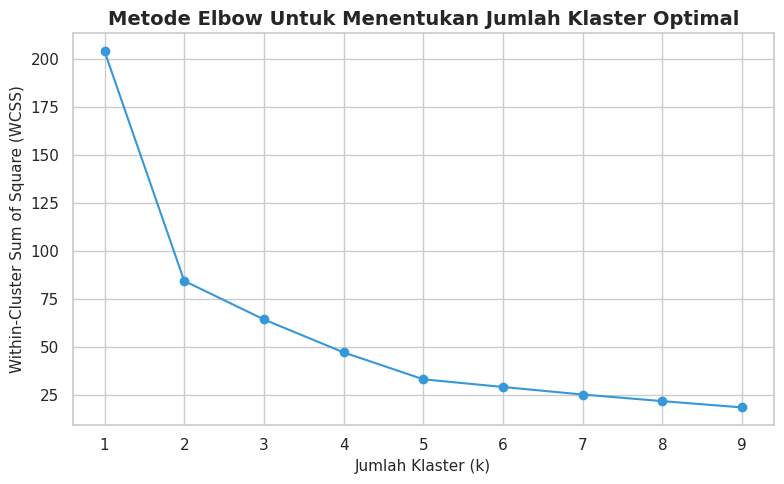

In [ ]:
wcss = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, 'bo-', marker='o', color='#3498db')
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Within-Cluster Sum of Square (WCSS)', fontsize=11)
plt.title('Metode Elbow Untuk Menentukan Jumlah Klaster Optimal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_elbow.png', dpi=300)
plt.show()

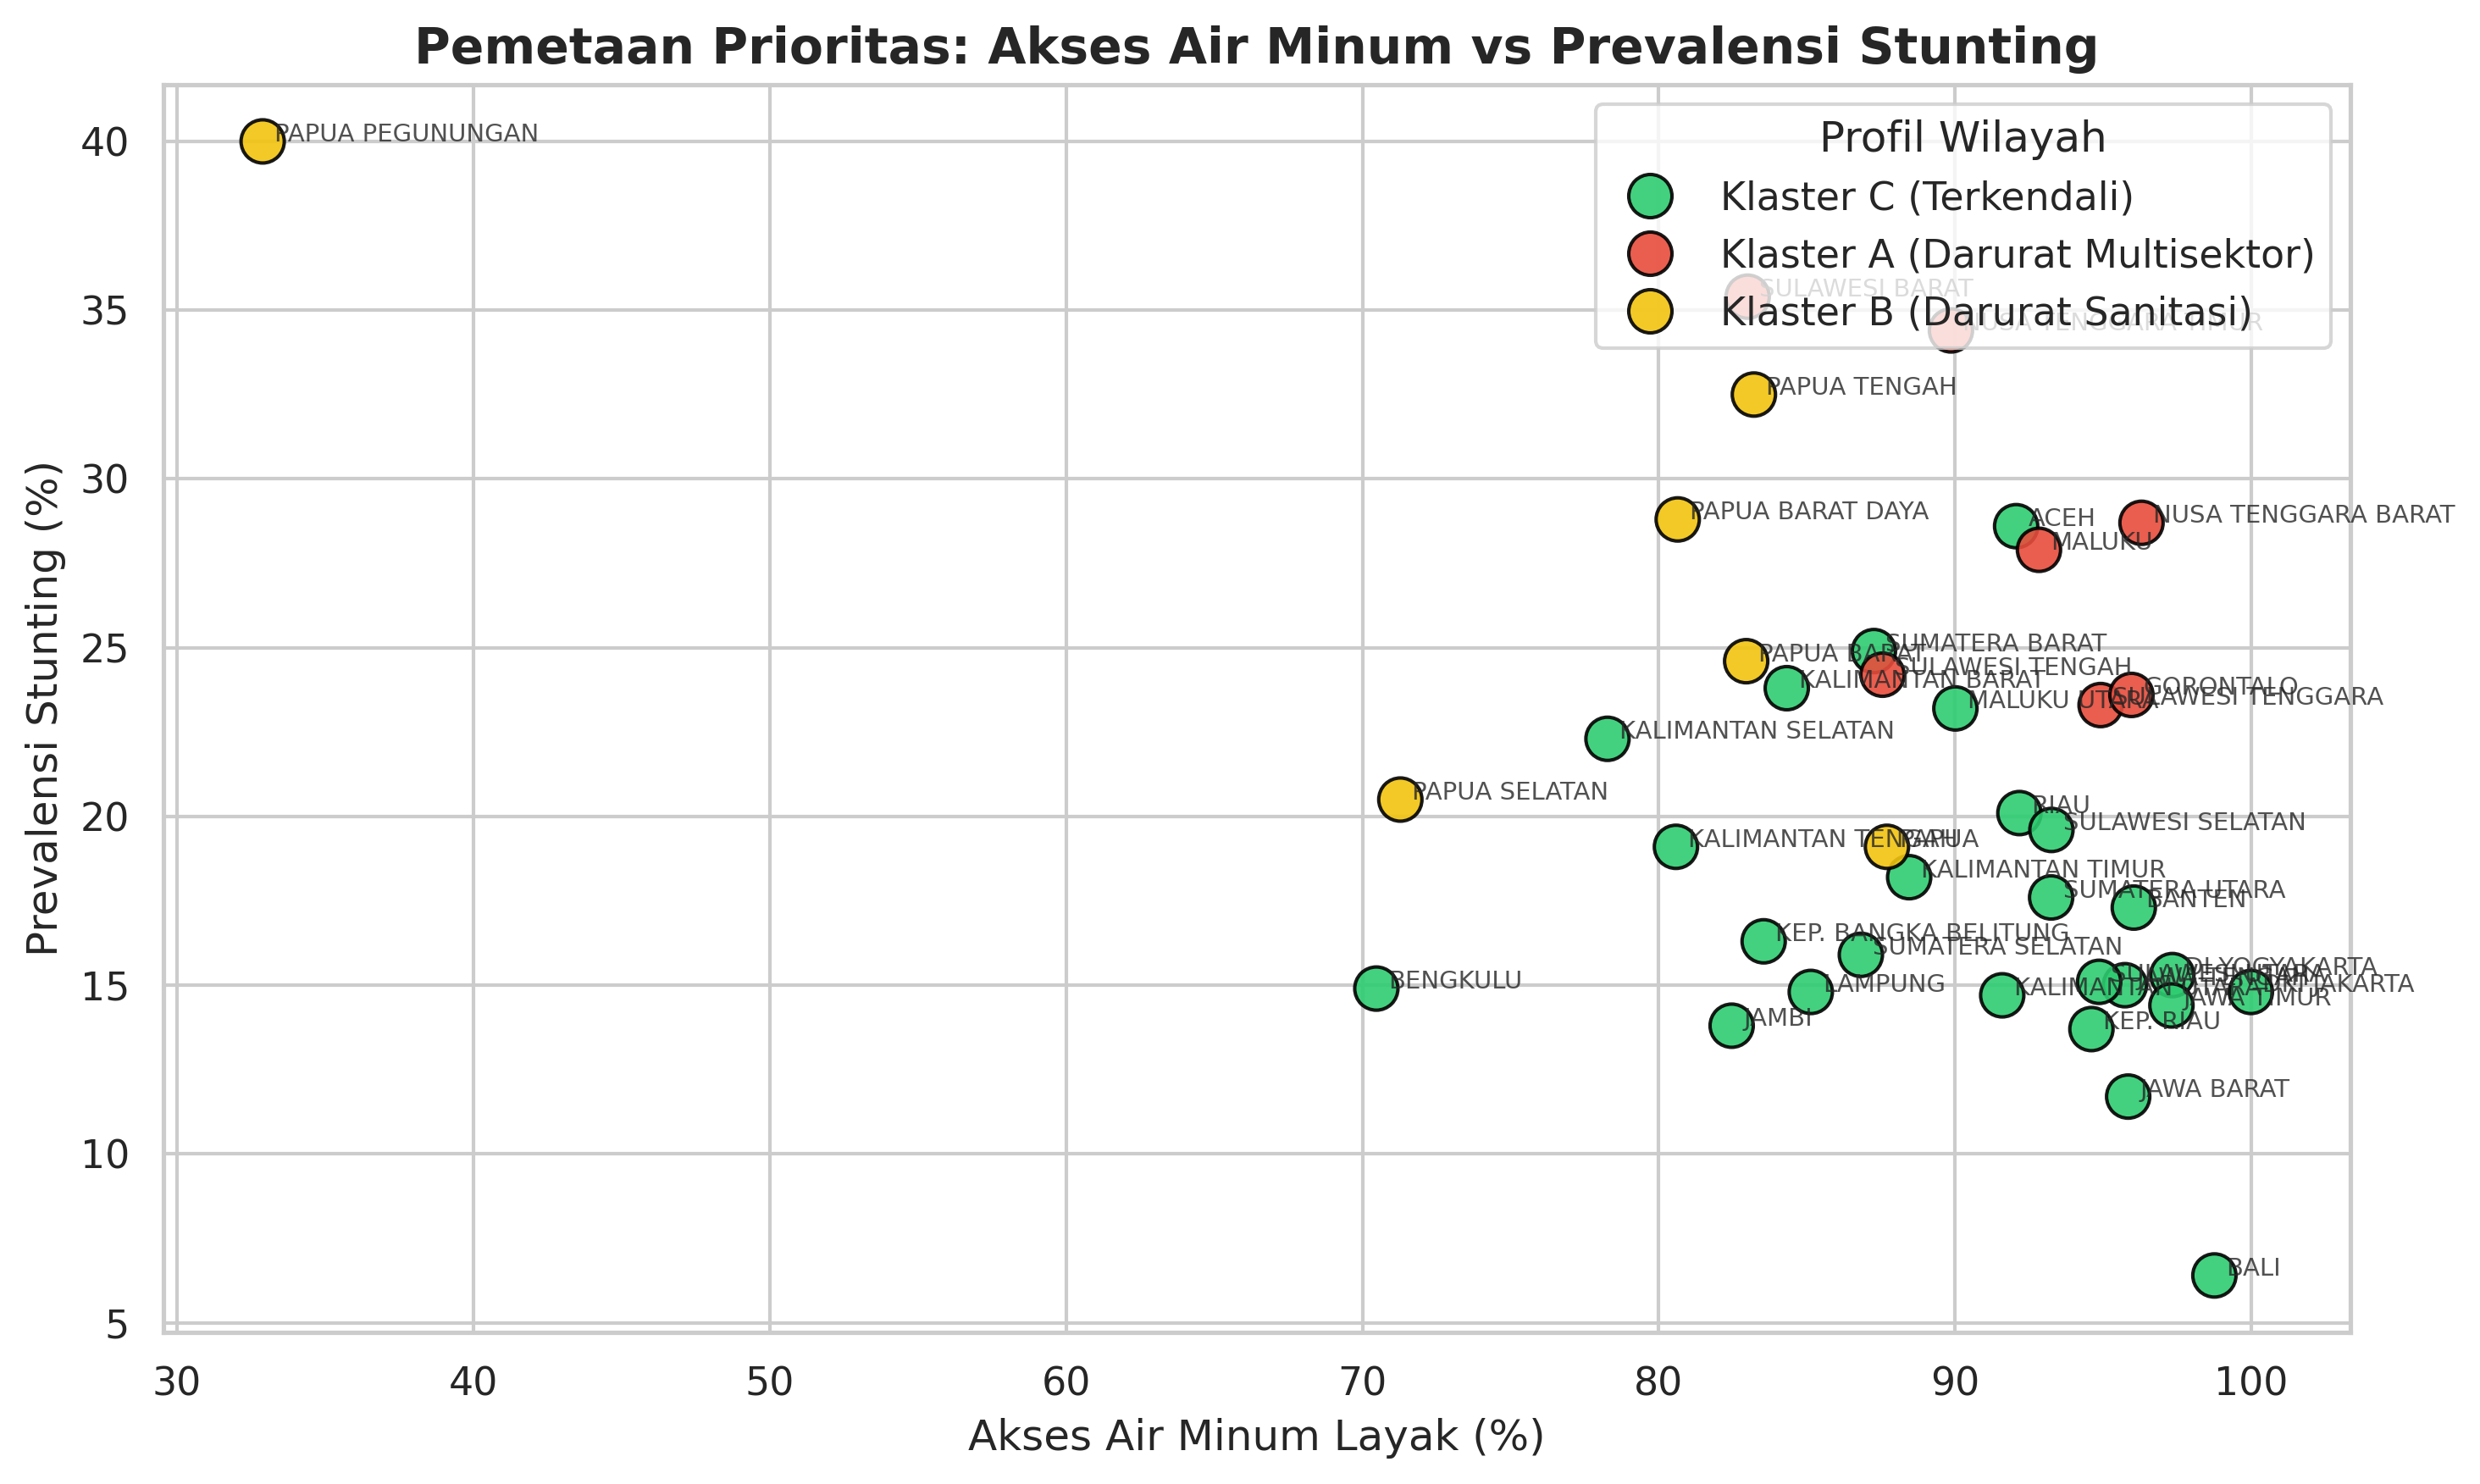

In [ ]:
plt.figure(figsize=(10, 6), dpi=300)
sns.scatterplot(data=df, x='Air_Layak', y='Stunting', hue='Kategori', palette=warna_klaster, s=150, alpha=0.9, edgecolor='black')

# Anotasi nama provinsi
for i in range(df.shape[0]):
    plt.text(df['Air_Layak'][i] + 0.4, df['Stunting'][i], df['Provinsi'][i], fontsize=7, alpha=0.8)

plt.title('Pemetaan Prioritas: Akses Air Minum vs Prevalensi Stunting', fontsize=14, fontweight='bold')
plt.xlabel('Akses Air Minum Layak (%)', fontsize=12)
plt.ylabel('Prevalensi Stunting (%)', fontsize=12)
plt.legend(title='Profil Wilayah', loc='upper right')
plt.tight_layout()
plt.savefig('plot2_scatter_air.png', dpi=300)
plt.show()

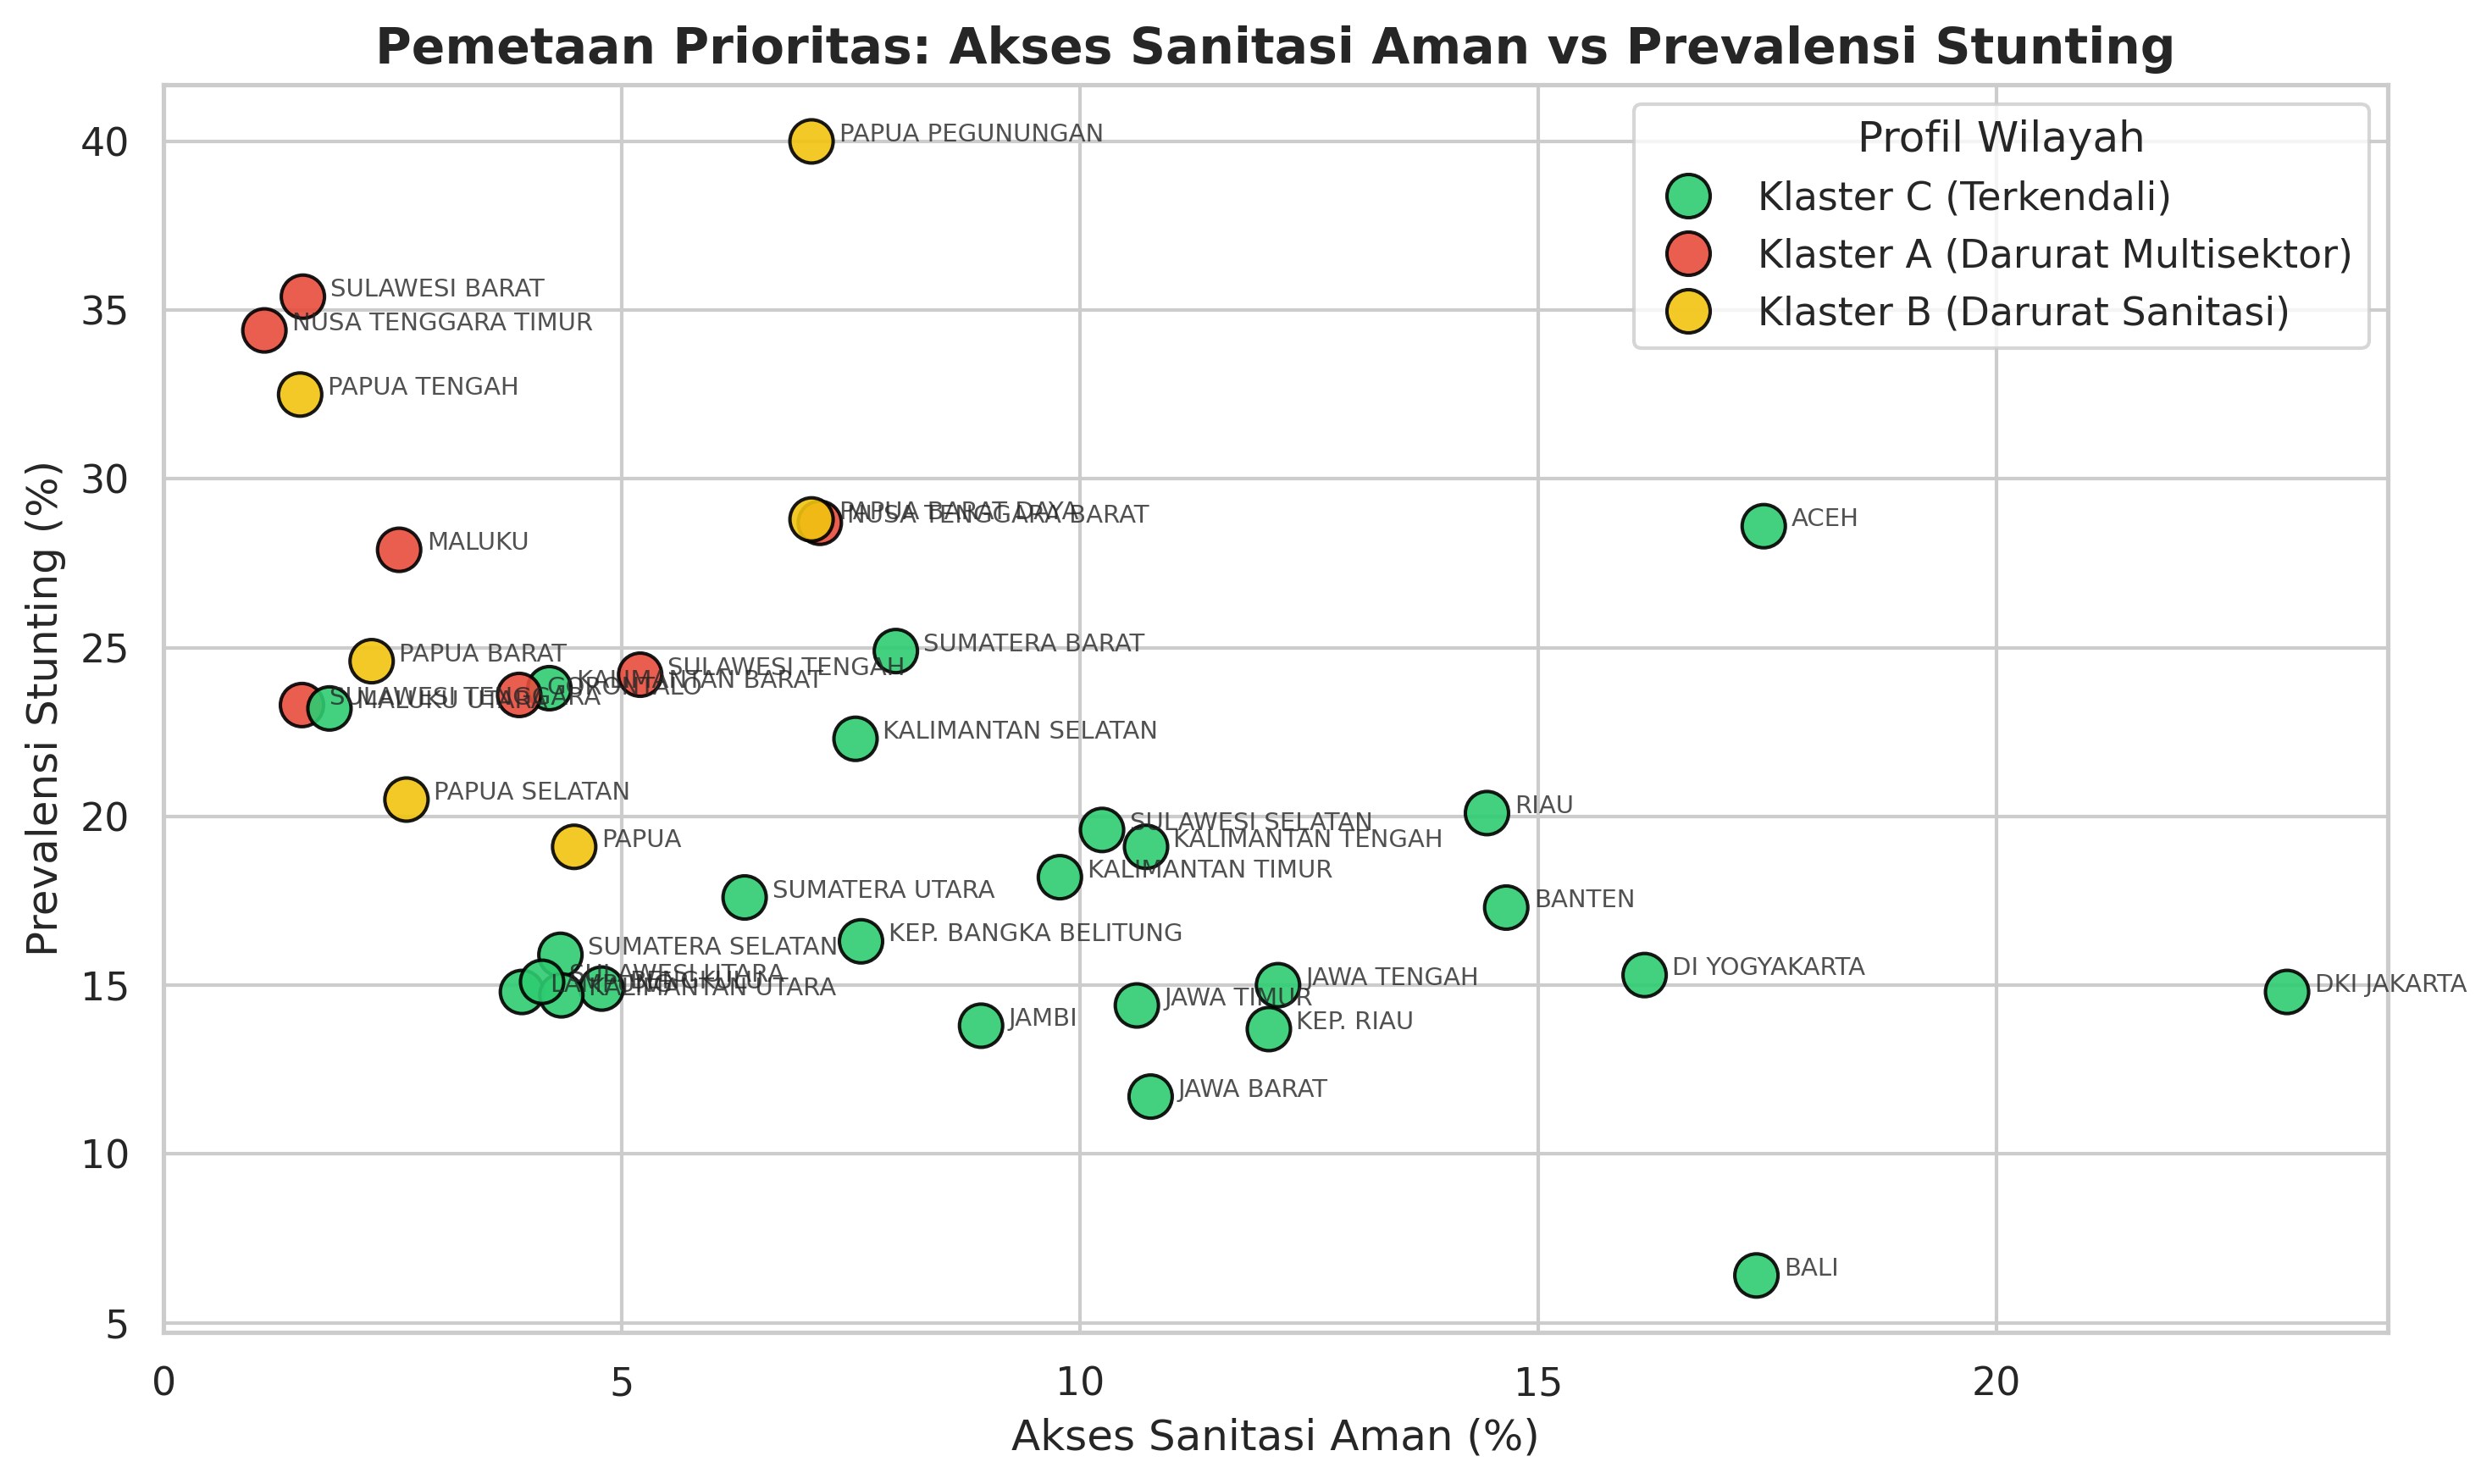

In [ ]:
plt.figure(figsize=(10, 6), dpi=300)
sns.scatterplot(data=df, x='Sanitasi_Aman', y='Stunting', hue='Kategori', palette=warna_klaster, s=150, alpha=0.9, edgecolor='black')

# Anotasi nama provinsi
for i in range(df.shape[0]):
    plt.text(df['Sanitasi_Aman'][i] + 0.3, df['Stunting'][i], df['Provinsi'][i], fontsize=7, alpha=0.8)

plt.title('Pemetaan Prioritas: Akses Sanitasi Aman vs Prevalensi Stunting', fontsize=14, fontweight='bold')
plt.xlabel('Akses Sanitasi Aman (%)', fontsize=12)
plt.ylabel('Prevalensi Stunting (%)', fontsize=12)
plt.legend(title='Profil Wilayah', loc='upper right')
plt.tight_layout()
plt.savefig('plot3_scatter_sanitasi.png', dpi=300)
plt.show()

In [ ]:
cluster_summary = df.groupby('Kategori')[features].mean().reset_index()
cluster_summary_melted = pd.melt(cluster_summary, id_vars='Kategori', var_name='Variabel', value_name='Rata-rata')

# Penyesuaian skala agar P2 Miskin terlihat sejajar dengan persentase di chart
cluster_summary_melted.loc[cluster_summary_melted['Variabel'] == 'P2_Miskin', 'Rata-rata'] *= 10
cluster_summary_melted.loc[cluster_summary_melted['Variabel'] == 'P2_Miskin', 'Variabel'] = 'P2_Miskin (x10)'

# Ubah nama variabel agar lebih rapi di grafik
nama_var_rapi = {
    'Stunting': 'Prevalensi Stunting (%)',
    'Air_Layak': 'Akses Air Layak (%)',
    'Sanitasi_Aman': 'Sanitasi Aman (%)',
    'P2_Miskin (x10)': 'Keparahan Kemiskinan (x10)'
}
cluster_summary_melted['Variabel'] = cluster_summary_melted['Variabel'].map(nama_var_rapi)

plt.figure(figsize=(12, 6), dpi=300)

<Figure size 3600x1800 with 0 Axes>

<Figure size 3600x1800 with 0 Axes>

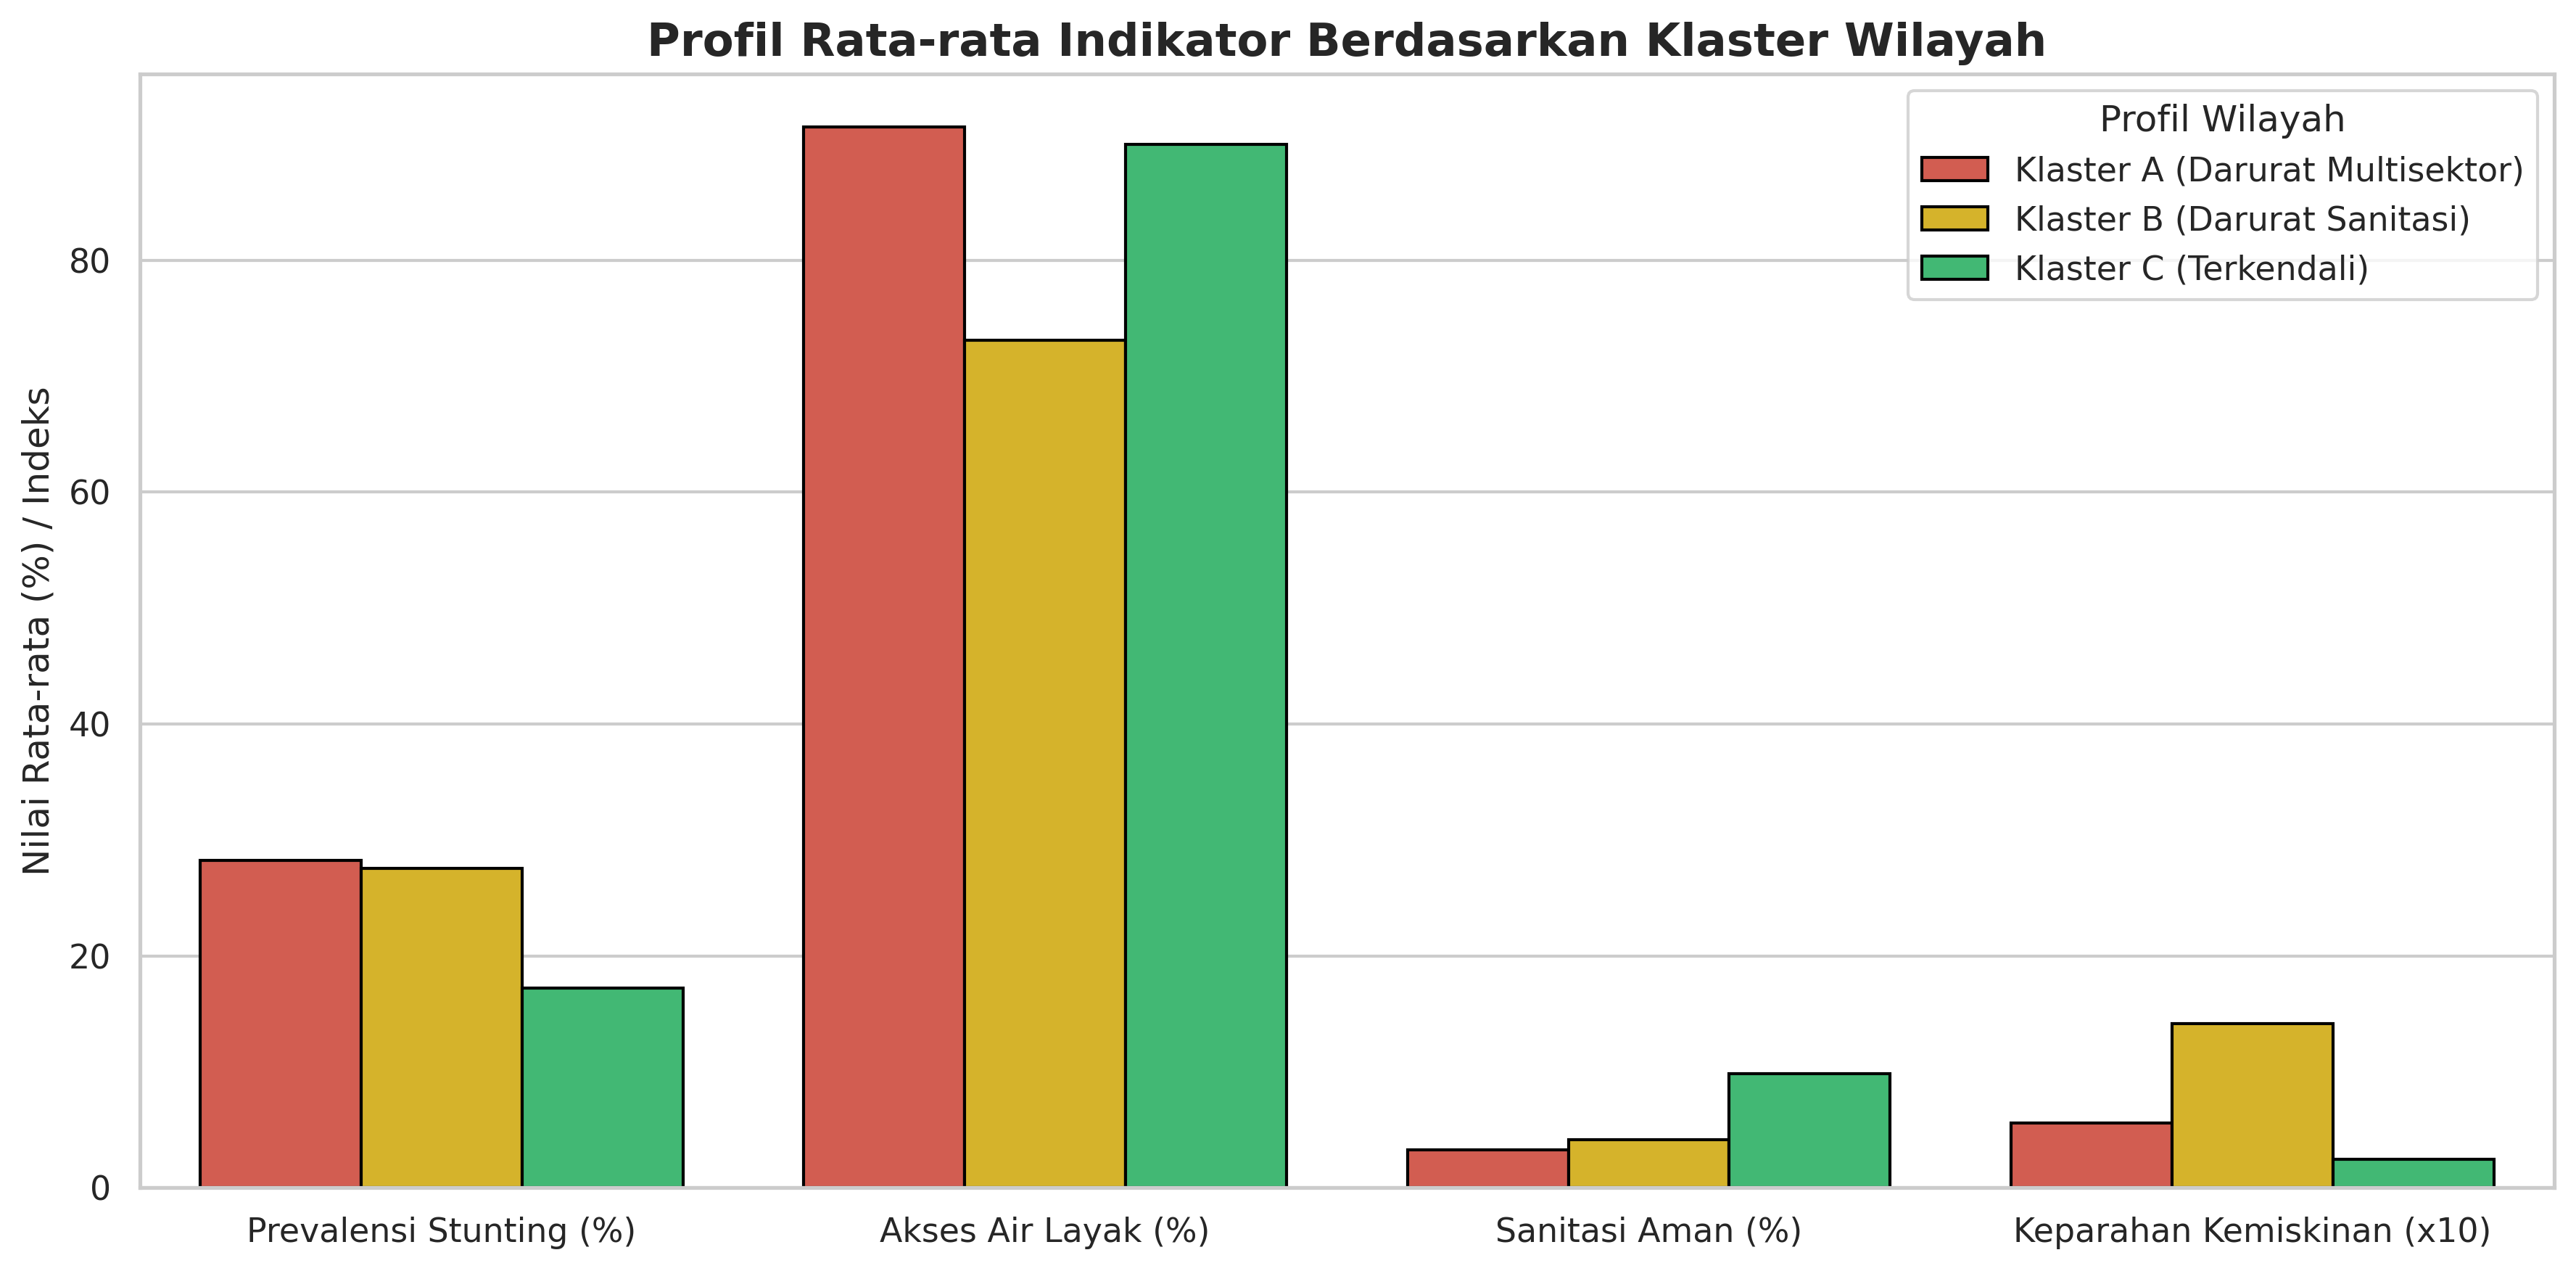

In [ ]:
plt.figure(figsize=(12, 6), dpi=300)
sns.barplot(data=cluster_summary_melted, x='Variabel', y='Rata-rata', hue='Kategori', palette=warna_klaster, edgecolor='black')

plt.title('Profil Rata-rata Indikator Berdasarkan Klaster Wilayah', fontsize=15, fontweight='bold')
plt.ylabel('Nilai Rata-rata (%) / Indeks', fontsize=12)
plt.xlabel('', fontsize=12)
plt.legend(title='Profil Wilayah')
plt.tight_layout()
plt.savefig('plot4_barplot.png', dpi=300)
plt.show()